In [8]:
import pandas as pd
import glob
import os


In [12]:


# 1. Cerchiamo i file .parquet prodotti dal toolkit nella cartella mart
path = "data/mart/terna_capacita_rinnovabile_provinciale/**/*.parquet"
files = glob.glob(path, recursive=True)

if not files:
    print("❌ Nessun file Parquet trovato in data/mart/!")
else:
    print(f"✅ Trovati {len(files)} file Parquet.")
    
    # Carichiamo e uniamo i file Parquet
    all_df = []
    for f in files:
        print(f"Caricamento: {f}")
        # Per leggere i parquet serve la libreria 'pyarrow' o 'fastparquet'
        temp_df = pd.read_parquet(f)
        all_df.append(temp_df)

    # Consolidamento in un unico dataframe storico
    df_storico = pd.concat(all_df, ignore_index=True)
    
    # Assicuriamoci che l'anno sia intero
    df_storico['anno'] = df_storico['anno'].astype(int)
    
    print("\n--- Caricamento completato ---")
    display(df_storico.head())

✅ Trovati 5 file Parquet.
Caricamento: data/mart/terna_capacita_rinnovabile_provinciale/2022/capacita_provinciale_unita.parquet
Caricamento: data/mart/terna_capacita_rinnovabile_provinciale/2024/capacita_provinciale_unita.parquet
Caricamento: data/mart/terna_capacita_rinnovabile_provinciale/2023/capacita_provinciale_unita.parquet
Caricamento: data/mart/terna_capacita_rinnovabile_provinciale/2021/capacita_provinciale_unita.parquet
Caricamento: data/mart/terna_capacita_rinnovabile_provinciale/2020/capacita_provinciale_unita.parquet

--- Caricamento completato ---


,anno,regione,provincia,fonti,potenza_totale_mw
0,2022,Abruzzo,Chieti,Eolico,160.796997
1,2022,Abruzzo,L'Aquila,Fotovoltaico,187.940994
2,2022,Abruzzo,L'Aquila,Geotermoelettrico,NaN
3,2022,Abruzzo,Pescara,Geotermoelettrico,NaN
4,2022,Abruzzo,Pescara,Fotovoltaico,107.392998


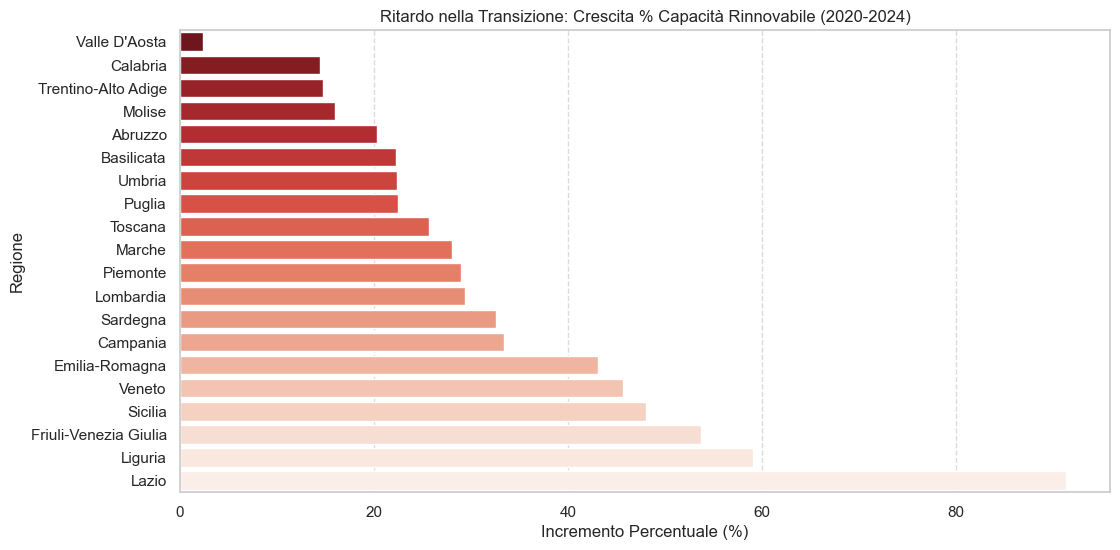

--- TOP 5 REGIONI PER CRESCITA PERCENTUALE ---


anno,crescita_pct,crescita_assoluta_mw
regione,,
Lazio,91.294693,1889.612994
Liguria,59.076041,177.146006
Friuli-Venezia Giulia,53.748274,657.317319
Sicilia,47.994472,1745.116935
Veneto,45.653875,1665.739413



--- 5 REGIONI PIÙ IN RITARDO ---


anno,crescita_pct,crescita_assoluta_mw
regione,,
Valle D'Aosta,2.338878,24.649992
Calabria,14.419670,393.525927
Trentino-Alto Adige,14.790128,583.496827
Molise,16.008498,110.210983
Abruzzo,20.308189,422.031987


In [13]:
# 1. Calcoliamo la potenza totale per regione e anno
pivot_regioni = df_storico.groupby(['regione', 'anno'])['potenza_totale_mw'].sum().unstack()

# 2. Calcolo della crescita (Delta) tra il 2020 e il 2024
pivot_regioni['crescita_assoluta_mw'] = pivot_regioni[2024] - pivot_regioni[2020]
pivot_regioni['crescita_pct'] = (pivot_regioni['crescita_assoluta_mw'] / pivot_regioni[2020]) * 100

# 3. Visualizzazione delle Regioni più "lente"
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
dati_grafico = pivot_regioni.sort_values(by='crescita_pct')
sns.barplot(x=dati_grafico['crescita_pct'], y=dati_grafico.index, palette="Reds_r")

plt.title("Ritardo nella Transizione: Crescita % Capacità Rinnovabile (2020-2024)")
plt.xlabel("Incremento Percentuale (%)")
plt.ylabel("Regione")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("--- TOP 5 REGIONI PER CRESCITA PERCENTUALE ---")
display(pivot_regioni.sort_values(by='crescita_pct', ascending=False).head(5)[['crescita_pct', 'crescita_assoluta_mw']])

print("\n--- 5 REGIONI PIÙ IN RITARDO ---")
display(pivot_regioni.sort_values(by='crescita_pct', ascending=True).head(5)[['crescita_pct', 'crescita_assoluta_mw']])

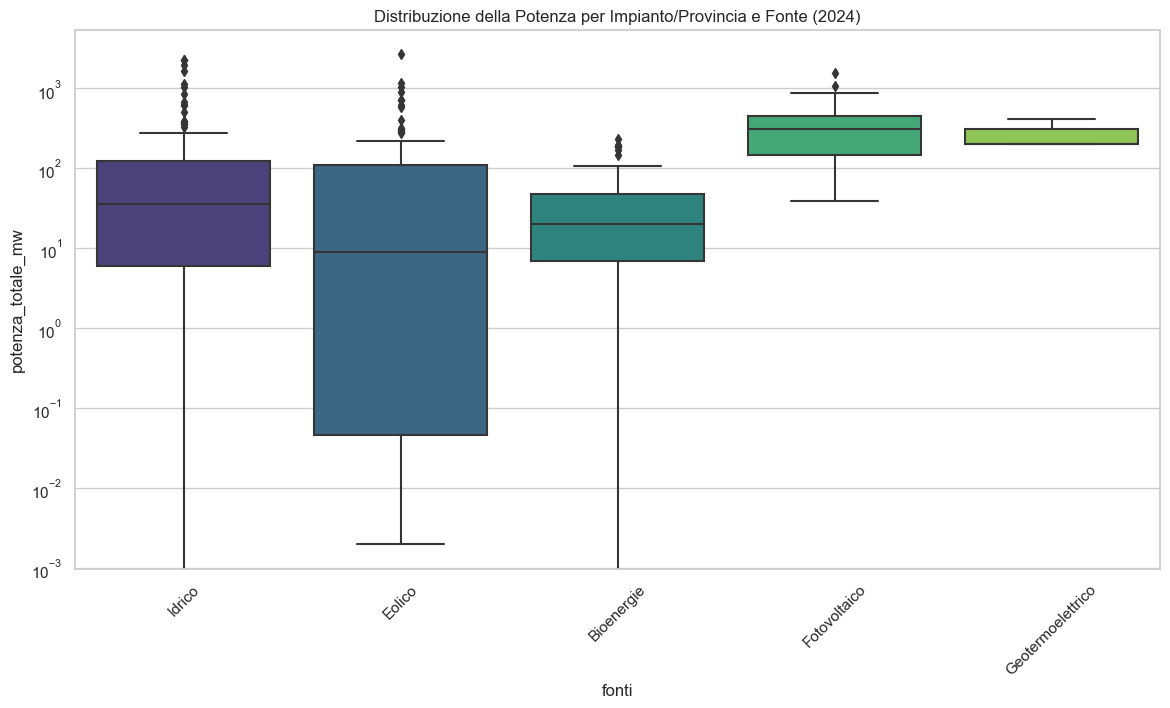

In [14]:
# Cella 3: Specializzazione per Fonte nel 2024
df_2024 = df_storico[df_storico['anno'] == 2024]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_2024, x='fonti', y='potenza_totale_mw', palette="viridis")
plt.yscale('log') # Usiamo scala logaritmica perché i valori variano molto tra fonti
plt.title("Distribuzione della Potenza per Impianto/Provincia e Fonte (2024)")
plt.xticks(rotation=45)
plt.show()

--- LE 10 PROVINCE CON LA MINOR CRESCITA DI POTENZA (% 2020-2024) ---


anno                                             2020         2024  \
regione             provincia                                        
Valle D'Aosta       Aosta                 1053.923976  1078.573969   
Lombardia           Sondrio               2323.134563  2387.993885   
Piemonte            Verbano-Cusio-Ossola   883.055528   913.156029   
Veneto              Belluno                698.054495   738.095013   
Umbria              Terni                  656.722999   702.448008   
Sicilia             Enna                   259.546001   278.408003   
Calabria            Crotone                792.862011   852.796989   
                    Catanzaro              980.694005  1070.607978   
Molise              Isernia                253.455004   278.110998   
Trentino-Alto Adige Trento                1845.991988  2032.170051   

anno                                      crescita_pct  
regione             provincia                           
Valle D'Aosta       Aosta                     2.338878  
Lombardia           Sondrio                   2.791888  
Piemonte            Verbano-Cusio-Ossola      3.408676  
Veneto              Belluno                   5.736016  
Umbria              Terni                     6.962602  
Sicilia             Enna                      7.267306  
Calabria            Crotone                   7.559320  
                    Catanzaro                 9.168402  
Molise              Isernia                   9.727957  
Trentino-Alto Adige Trento                   10.085529

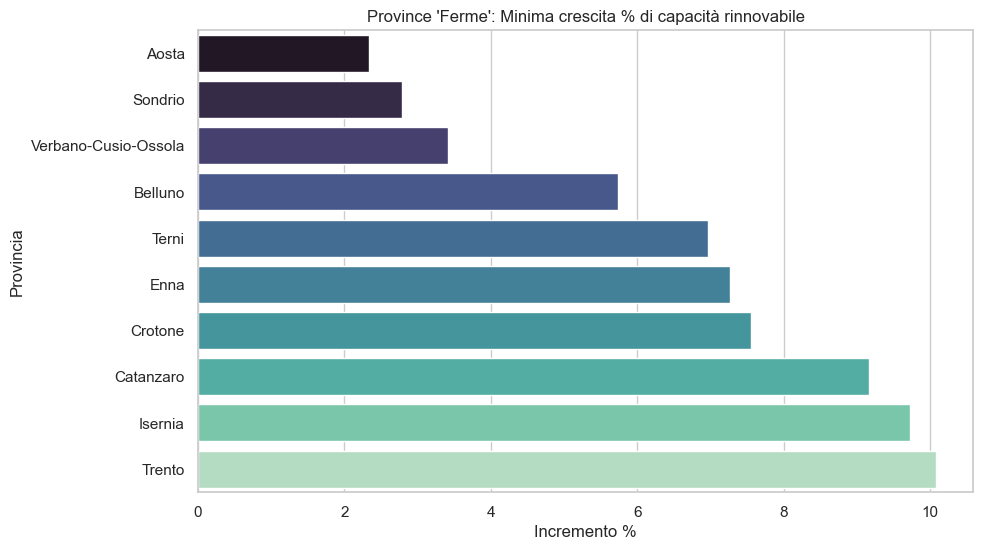

In [15]:
# 1. Aggreghiamo per provincia e anno
pivot_prov = df_storico.groupby(['regione', 'provincia', 'anno'])['potenza_totale_mw'].sum().unstack()

# 2. Calcolo crescita percentuale provinciale
# Usiamo fillna(0) per gestire eventuali province con dati mancanti nel 2020
pivot_prov['crescita_pct'] = ((pivot_prov[2024] - pivot_prov[2020]) / pivot_prov[2020].replace(0, 1)) * 100

# 3. Isoliamo le 10 province con la crescita più bassa
# Filtriamo quelle che hanno almeno un minimo di potenza installata (> 5MW) per evitare errori statistici
province_ritardo = pivot_prov[pivot_prov[2020] > 5].sort_values(by='crescita_pct').head(10)

print("--- LE 10 PROVINCE CON LA MINOR CRESCITA DI POTENZA (% 2020-2024) ---")
display(province_ritardo[[2020, 2024, 'crescita_pct']])

# 4. Grafico rapido delle province in stallo
plt.figure(figsize=(10, 6))
sns.barplot(x=province_ritardo['crescita_pct'], y=province_ritardo.index.get_level_values('provincia'), palette="mako")
plt.title("Province 'Ferme': Minima crescita % di capacità rinnovabile")
plt.xlabel("Incremento %")
plt.ylabel("Provincia")
plt.show()

In [16]:
# Creazione del file finale consolidato
file_output = "terna_capacita_rinnovabile_provinciale_2020_2024.csv"

# Ordiniamo per rendere il file leggibile
df_final = df_storico.sort_values(by=['anno', 'regione', 'provincia', 'fonti'])

# Salvataggio
df_final.to_csv(file_output, index=False, encoding='utf-8')

print(f"✅ File consolidato generato: {file_output}")
print(f"Dimensioni: {df_final.shape[0]} righe e {df_final.shape[1]} colonne.")

✅ File consolidato generato: terna_capacita_rinnovabile_provinciale_2020_2024.csv
Dimensioni: 2649 righe e 5 colonne.
